In [38]:
import pandas as pd
import numpy as np

# URL for the full CFPB complaints dataset
cfpb_full_url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

print("Downloading CFPB dataset (2020+) with complaint narratives...")
print("="*80)

chunks = []
chunk_size = 100000
total_rows = 0

for chunk in pd.read_csv(cfpb_full_url, compression='zip', low_memory=False, chunksize=chunk_size):
    
    # Convert date column
    chunk['Date received'] = pd.to_datetime(chunk['Date received'], errors='coerce')
    
    # Filter for 2020+
    chunk = chunk[chunk['Date received'] >= '2020-01-01']
    
    # Keep only rows with narratives (since this is an NLP project)
    chunk = chunk[chunk['Consumer complaint narrative'].notna()]
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if total_rows >= 150000:
        break

df_full = pd.concat(chunks, ignore_index=True)

print(f"✓ Dataset loaded successfully!")
print(f"Shape: {df_full.shape}")
print(f"Date range: {df_full['Date received'].min()} to {df_full['Date received'].max()}")


✓ Dataset loaded successfully!
Shape: (165605, 18)
Date range: 2020-01-01 00:00:00 to 2026-02-05 00:00:00


In [39]:
df_full

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453
1,2024-01-05,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,2024-01-05,Closed with non-monetary relief,Yes,NaN,8113747
2,2020-03-19,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"I wrote three requests, the unverified account...",NaN,"EQUIFAX, INC.",NC,28562,NaN,Consent provided,Web,2020-03-19,Closed with explanation,Yes,NaN,3573294
3,2020-03-29,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Keep getting calls about your loan,They call at all hours and on the weekends usi...,NaN,"Navient Solutions, LLC.",CA,92028,Servicemember,Consent provided,Web,2020-03-29,Closed with explanation,Yes,NaN,3584679
4,2020-03-17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I was recently going to check out a new car at...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AR,72211,NaN,Consent provided,Web,2020-03-17,Closed with explanation,Yes,NaN,3569824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165600,2023-05-26,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I Have been a victim I have had someone use my...,NaN,"Exeter Finance, LLC.",CA,92551,NaN,Consent provided,Web,2023-05-26,Closed with explanation,Yes,NaN,7035247
165601,2025-09-12,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,I AM REQUESTING THE IMMEDIATE REMOVAL OF THIS ...,NaN,"EQUIFAX, INC.",AR,722XX,NaN,Consent provided,Web,2025-09-12,Closed with non-monetary relief,Yes,NaN,15909568
165602,2025-11-19,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,"PLEASE, I'M BEGGING YOU TO REMOVE THE FRAUDULE...",NaN,"EQUIFAX, INC.",TX,78521,NaN,Consent provided,Web,2025-11-19,Closed with non-monetary relief,Yes,NaN,17318266
165603,2025-12-26,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Personal information incorrect,I am submitting this complaint regarding unaut...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,XXXXX,NaN,Consent provided,Web,2025-12-26,Closed with explanation,Yes,NaN,18296707


## 🚨 Fraud Detection in CFPB Complaints Data

The CFPB dataset isn't primarily about detecting **fraudulent complaints** (fake reports), but rather about identifying **fraud-related complaint patterns** - i.e., complaints about financial fraud perpetrated against consumers.

Here's what we can analyze:

### 🎯 **Option 1: Fraud-Related Complaint Detection** (Recommended)

**What it means**: Identify complaints that describe fraudulent activity by financial institutions or identity theft.

#### **Fraud Patterns to Detect**:

1. **Identity Theft & Fraud Issues**
   - Issue category: "Fraud or scam"
   - Sub-issues: 
     - "Account opened as a result of fraud"
     - "Fraud or scam"
     - "Identity theft"
     - "Transaction was not authorized"
   
2. **Unauthorized Transactions**
   - Credit card charges the consumer didn't make
   - Bank withdrawals without permission
   - Loan applications in consumer's name without their knowledge

3. **Scam Products**
   - Predatory lending patterns
   - Deceptive mortgage practices
   - Misleading credit card offers

4. **Text-Based Fraud Indicators** (from complaint narratives):
   - Keywords: "fraud", "scam", "stolen", "unauthorized", "identity theft", "hacked", "phishing"
   - Patterns: 
     - "I did not authorize..."
     - "Someone opened an account in my name..."
     - "My card was used without my permission..."
     - "I was a victim of..."

---

### 📊 **Supervised Learning Task: Fraud Complaint Classification**

**Goal**: Build a binary classifier to predict if a complaint involves fraud/identity theft

**Target Variable**:
- Create from Issue/Sub-issue categories OR
- Extract from complaint narrative text using NLP

**Features**:
- **Text features**: TF-IDF or BERT embeddings from complaint narratives
- **Categorical**: Product type, issue category, submission method
- **Behavioral**: Time to company response, whether disputed
- **Geographic**: State patterns (some states have higher fraud rates)

**Models**:
- Logistic Regression (interpretable baseline)
- Random Forest (handle categorical + text features)
- XGBoost (likely best performance)
- BERT-based classifier (state-of-the-art for text)

**Evaluation**:
- Precision/Recall (important: minimize false positives)
- F1-score
- ROC-AUC
- Confusion matrix analysis

**Why it's novel**:
- Most CFPB studies focus on company response prediction
- Fraud detection angle is **more practical and policy-relevant**
- Combines structured data + NLP for hybrid approach

In [40]:
# Confirm dataset is loaded
try:
    print(f"Dataset loaded: {df_full.shape}")
except:
    raise Exception("Run the data loading cell first.")

print("\n" + "="*80)
print("🔍 STEP 1: Create Fraud Label from Structured Fields Only")
print("="*80)

# Define fraud-related keywords for Issue/Sub-issue
fraud_keywords_issue = [
    'fraud', 
    'scam', 
    'identity theft', 
    'unauthorized', 
    'stolen', 
    'transaction was not authorized'
]

# Fraud detection using Issue column
df_full['is_fraud_issue'] = df_full['Issue'].str.lower().str.contains(
    '|'.join(fraud_keywords_issue),
    na=False
)

# Fraud detection using Sub-issue column (if available)
if 'Sub-issue' in df_full.columns:
    df_full['is_fraud_subissue'] = df_full['Sub-issue'].str.lower().str.contains(
        '|'.join(fraud_keywords_issue),
        na=False
    )
else:
    df_full['is_fraud_subissue'] = False

# Final fraud label (STRUCTURED ONLY — no narrative used)
df_full['is_fraud'] = df_full['is_fraud_issue'] | df_full['is_fraud_subissue']

print("\n📊 FINAL FRAUD LABEL STATISTICS")
print("="*80)
print(f"Total complaints: {len(df_full):,}")
print(f"Fraud complaints: {df_full['is_fraud'].sum():,}")
print(f"Fraud percentage: {df_full['is_fraud'].mean()*100:.2f}%")
print(f"Non-fraud complaints: {(~df_full['is_fraud']).sum():,}")

print("\n📦 Top Products Among Fraud Complaints:")
print(df_full[df_full['is_fraud']]['Product'].value_counts().head(10))


Dataset loaded: (165605, 18)

🔍 STEP 1: Create Fraud Label from Structured Fields Only

📊 FINAL FRAUD LABEL STATISTICS
Total complaints: 165,605
Fraud complaints: 6,244
Fraud percentage: 3.77%
Non-fraud complaints: 159,361

📦 Top Products Among Fraud Complaints:
Product
Debt collection                                                                 2274
Money transfer, virtual currency, or money service                              1469
Checking or savings account                                                      924
Credit reporting or other personal consumer reports                              798
Credit reporting, credit repair services, or other personal consumer reports     446
Credit card or prepaid card                                                      184
Vehicle loan or lease                                                             78
Debt or credit management                                                         23
Student loan                                     

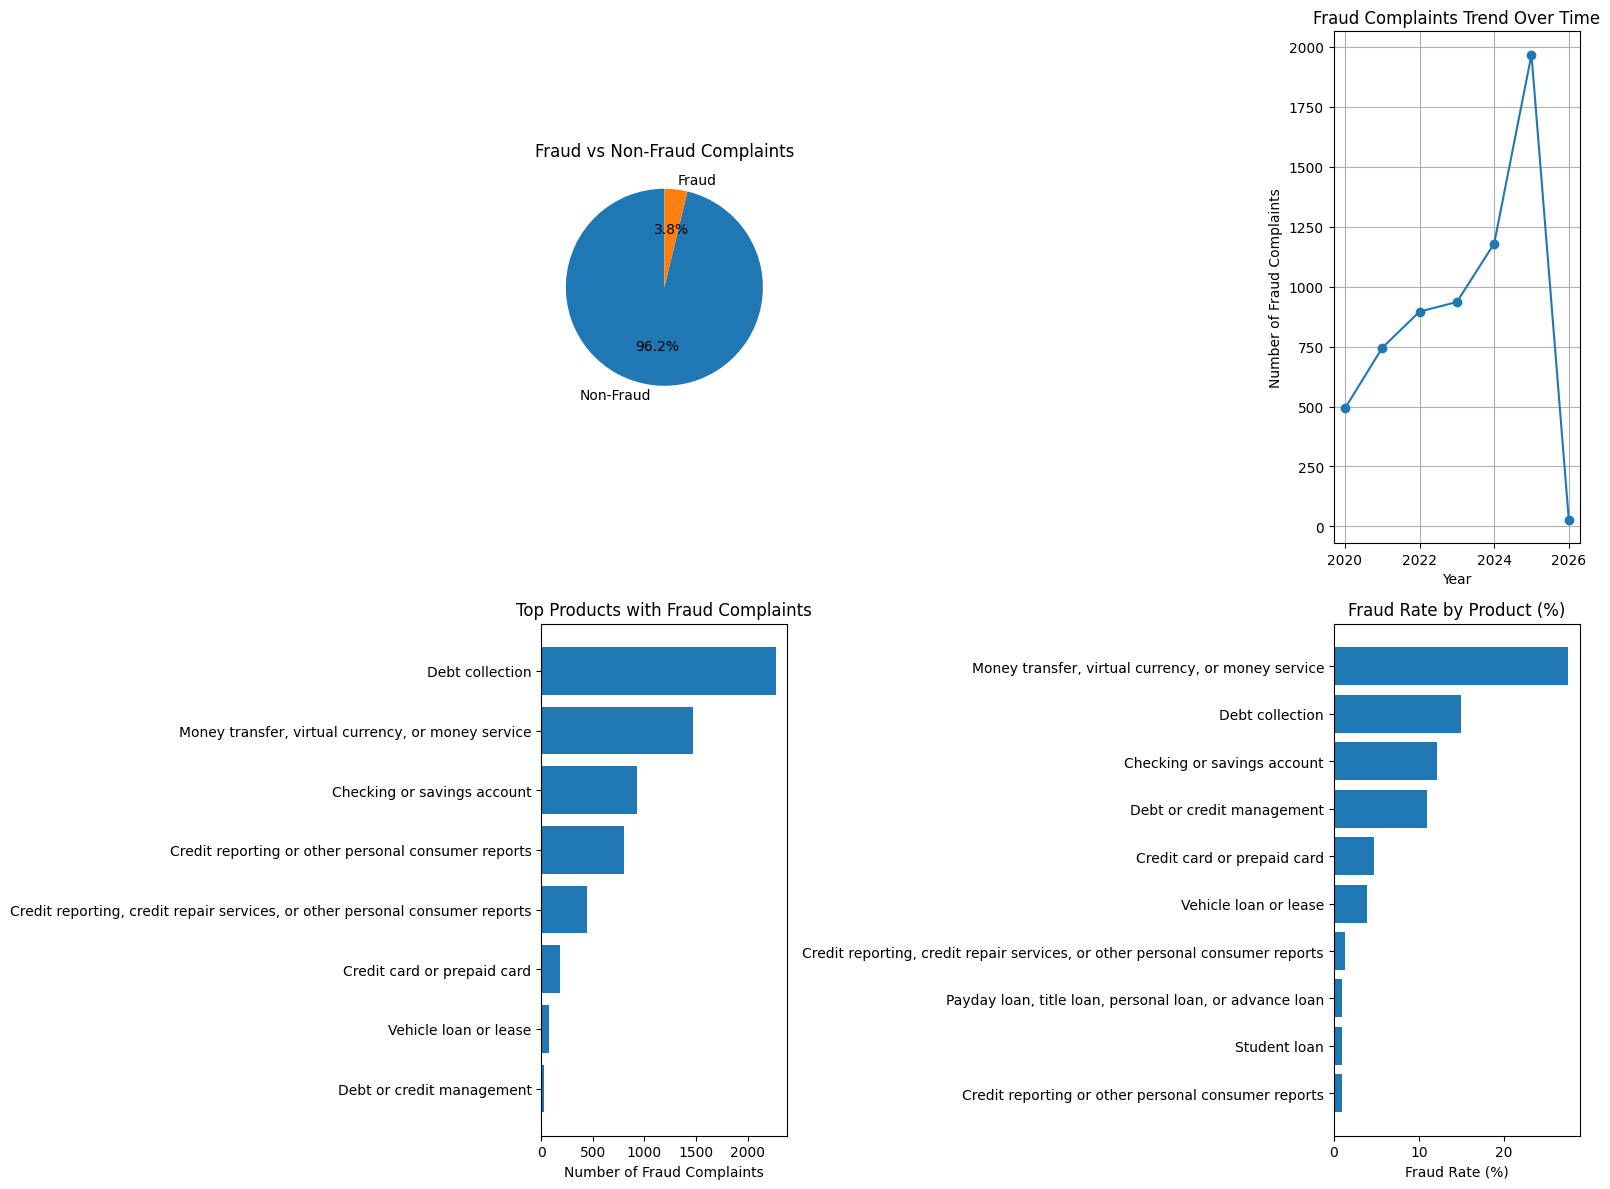


🎯 Key Insights
1. Fraud complaints represent 3.77% of all complaints.
2. Most common fraud product: Debt collection
3. Highest fraud rate product: Money transfer, virtual currency, or money service (27.55%)
4. Fraud trend appears decreasing from 2020 to 2026.


In [41]:
# ==========================================================
# 📊 Exploratory Data Analysis (EDA) – Fraud Overview
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ----------------------------------------------------------
# 1️⃣ Fraud vs Non-Fraud Distribution
# ----------------------------------------------------------

fraud_counts = df_full['is_fraud'].value_counts()

axes[0, 0].pie(
    fraud_counts.values,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title('Fraud vs Non-Fraud Complaints')

# ----------------------------------------------------------
# 2️⃣ Fraud Trend Over Time
# ----------------------------------------------------------

fraud_by_year = (
    df_full[df_full['is_fraud']]
    .groupby(df_full['Date received'].dt.year)
    .size()
)

axes[0, 1].plot(
    fraud_by_year.index,
    fraud_by_year.values,
    marker='o'
)

axes[0, 1].set_title('Fraud Complaints Trend Over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Fraud Complaints')
axes[0, 1].grid(True)

# ----------------------------------------------------------
# 3️⃣ Top Products by Fraud Volume
# ----------------------------------------------------------

top_fraud_products = (
    df_full[df_full['is_fraud']]
    ['Product']
    .value_counts()
    .head(8)
)

axes[1, 0].barh(
    top_fraud_products.index,
    top_fraud_products.values
)

axes[1, 0].set_title('Top Products with Fraud Complaints')
axes[1, 0].set_xlabel('Number of Fraud Complaints')
axes[1, 0].invert_yaxis()

# ----------------------------------------------------------
# 4️⃣ Fraud Rate by Product (%)
# ----------------------------------------------------------

fraud_rate_by_product = (
    df_full.groupby('Product')['is_fraud']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

axes[1, 1].barh(
    fraud_rate_by_product.index,
    fraud_rate_by_product.values
)

axes[1, 1].set_title('Fraud Rate by Product (%)')
axes[1, 1].set_xlabel('Fraud Rate (%)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 📌 Summary Insights
# ----------------------------------------------------------

print("\n" + "="*80)
print("🎯 Key Insights")
print("="*80)

fraud_percentage = df_full['is_fraud'].mean() * 100

print(f"1. Fraud complaints represent {fraud_percentage:.2f}% of all complaints.")

if len(top_fraud_products) > 0:
    print(f"2. Most common fraud product: {top_fraud_products.index[0]}")

if len(fraud_rate_by_product) > 0:
    print(f"3. Highest fraud rate product: {fraud_rate_by_product.index[0]} "
          f"({fraud_rate_by_product.values[0]:.2f}%)")

if len(fraud_by_year) > 1:
    trend = "increasing" if fraud_by_year.iloc[-1] > fraud_by_year.iloc[0] else "decreasing"
    print(f"4. Fraud trend appears {trend} from "
          f"{fraud_by_year.index[0]} to {fraud_by_year.index[-1]}.")


In [42]:
# ==========================================================
# Text Cleaning & Feature Engineering
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'x+', 'x', text)            # collapse redacted text
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning complaint narratives...")
df_full['narrative_clean'] = df_full['Consumer complaint narrative'].apply(clean_text)

# ----------------------------------------------------------
# 📅 Temporal Features
# ----------------------------------------------------------

df_full['Date received'] = pd.to_datetime(df_full['Date received'])

df_full['Year'] = df_full['Date received'].dt.year
df_full['Month'] = df_full['Date received'].dt.month
df_full['Quarter'] = df_full['Date received'].dt.quarter
df_full['DayOfWeek'] = df_full['Date received'].dt.dayofweek

# ----------------------------------------------------------
# 📝 Text Meta Features
# ----------------------------------------------------------

df_full['narrative_length'] = df_full['narrative_clean'].apply(len)
df_full['word_count'] = df_full['narrative_clean'].apply(lambda x: len(x.split()))

print("✅ Feature engineering complete")
df_full[['narrative_clean', 'narrative_length', 'word_count']].head()


Cleaning complaint narratives...
✅ Feature engineering complete


,narrative_clean,narrative_length,word_count
0,these are not my accounts,25,5
1,kindly address this issue on my credit report ...,207,36
2,i wrote three requests the unverified accounts...,1012,185
3,they call at all hours and on the weekends usi...,64,12
4,i was recently going to check out a new car at...,420,90


In [43]:
# ==========================================================
# ⏳ STEP 4: Time-Based Train/Test Split
# ==========================================================

# Sort by date
df_full = df_full.sort_values("Date received")

# 80% train, 20% test chronologically
split_index = int(len(df_full) * 0.8)

train_df = df_full.iloc[:split_index]
test_df = df_full.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

print("\nFraud rate (Train):", train_df['is_fraud'].mean())
print("Fraud rate (Test):", test_df['is_fraud'].mean())


Train size: (132484, 28)
Test size: (33121, 28)

Fraud rate (Train): 0.03862353189819148
Fraud rate (Test): 0.03402675040004831


In [44]:
# ==========================================================
# 🎯 STEP 5: Prepare Modeling Data (NO LEAKAGE)
# ==========================================================

# Ensure target exists
if 'is_fraud' not in df_full.columns:
    raise ValueError("Missing 'is_fraud' column. Run fraud detection cell first.")

print("Fraud Rate (Train):", train_df['is_fraud'].mean())
print("Fraud Rate (Test):", test_df['is_fraud'].mean())

# Drop missing narrative rows
train_df = train_df.dropna(subset=['narrative_clean']).copy()
test_df = test_df.dropna(subset=['narrative_clean']).copy()

# ----------------------------------------------------------
# TF-IDF (FIT ON TRAIN ONLY)
# ----------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

print("\nCreating TF-IDF features (train only)...")

tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.7,
    stop_words='english',
    ngram_range=(1,2)
)

X_train_text = tfidf.fit_transform(train_df['narrative_clean'])
X_test_text = tfidf.transform(test_df['narrative_clean'])

print("TF-IDF features:", X_train_text.shape[1])

# Targets
y_train = train_df['is_fraud']
y_test = test_df['is_fraud']


Fraud Rate (Train): 0.03862353189819148
Fraud Rate (Test): 0.03402675040004831

Creating TF-IDF features (train only)...
TF-IDF features: 1000


In [45]:
# ==========================================================
# 🔧 STEP 6: Add Structured Features (Hybrid Model)
# ==========================================================

from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Structured features to include
categorical_features = ['Product', 'State']
numeric_features = ['Year', 'Month', 'Quarter', 'DayOfWeek',
                    'narrative_length', 'word_count']

# ----------------------------------------------------------
# OneHot Encode categorical features (FIT ON TRAIN ONLY)
# ----------------------------------------------------------

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_train_cat = ohe.fit_transform(train_df[categorical_features].fillna('Unknown'))
X_test_cat = ohe.transform(test_df[categorical_features].fillna('Unknown'))

# ----------------------------------------------------------
# Numeric features (convert to sparse)
# ----------------------------------------------------------

X_train_num = sp.csr_matrix(train_df[numeric_features].values)
X_test_num = sp.csr_matrix(test_df[numeric_features].values)

# ----------------------------------------------------------
# Combine ALL features
# ----------------------------------------------------------

X_train_final = sp.hstack([X_train_text, X_train_cat, X_train_num])
X_test_final = sp.hstack([X_test_text, X_test_cat, X_test_num])

print("Final training matrix shape:", X_train_final.shape)
print("Final test matrix shape:", X_test_final.shape)
print("Total features:", X_train_final.shape[1])


Final training matrix shape: (132484, 1080)
Final test matrix shape: (33121, 1080)
Total features: 1080


In [46]:
X_train_final.toarray()

array([[0.000e+00, 0.000e+00, 0.000e+00, ..., 2.000e+00, 7.050e+02,
        1.260e+02],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.000e+00, 3.780e+02,
        6.900e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.000e+00, 5.260e+02,
        1.040e+02],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 4.000e+00, 2.136e+03,
        3.650e+02],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 4.000e+00, 3.440e+02,
        6.000e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 4.000e+00, 8.890e+02,
        2.430e+02]])

In [47]:
# ==========================================================
# 🤖 STEP 7: Train Baseline Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr_model.fit(X_train_final, y_train)

training_time = time.time() - start
print(f"Training completed in {training_time:.2f} seconds\n")

# Predictions
y_pred_lr = lr_model.predict(X_test_final)
y_prob_lr = lr_model.predict_proba(X_test_final)[:, 1]

# Evaluation
print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Fraud','Fraud']))

cm = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm)

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


Training Logistic Regression...
Training completed in 35.67 seconds

LOGISTIC REGRESSION RESULTS

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.86      0.92     31994
       Fraud       0.18      0.89      0.30      1127

    accuracy                           0.86     33121
   macro avg       0.59      0.87      0.61     33121
weighted avg       0.97      0.86      0.90     33121


Confusion Matrix:
[[27476  4518]
 [  123  1004]]

ROC-AUC: 0.9237


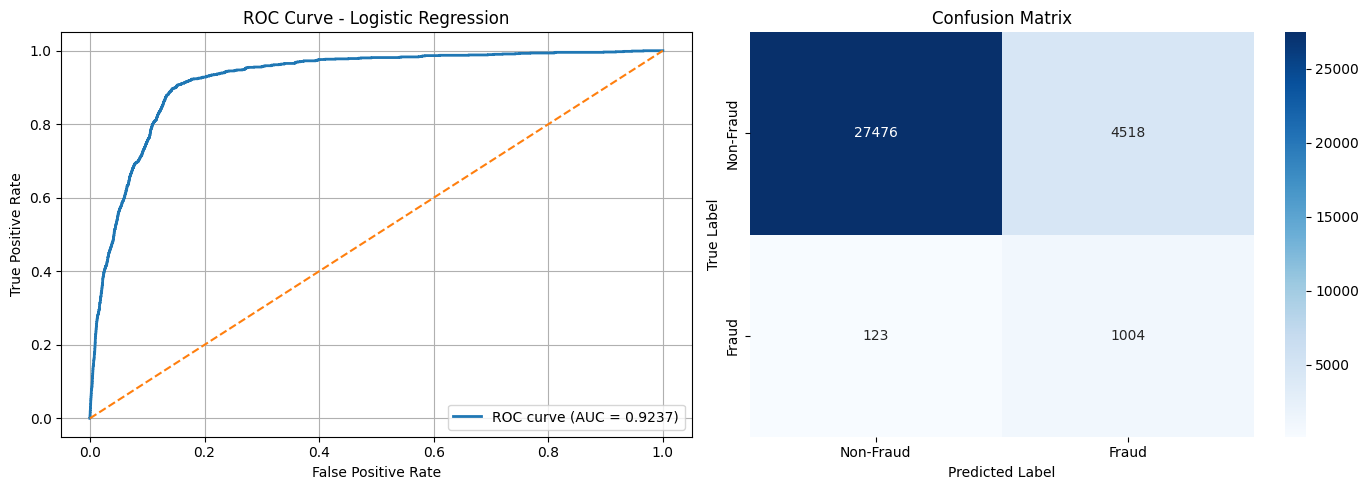

✅ Logistic Regression visualization complete.


In [48]:
# ==========================================================
# 📊 STEP 8: Visualize Logistic Regression Performance
# ==========================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

axes[0].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {auc_lr:.4f})')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Logistic Regression')
axes[0].legend()
axes[0].grid(True)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print("✅ Logistic Regression visualization complete.")


Best F1 threshold: 0.8617667448092714
Best F2 threshold (recall focused): 0.5258310231031893


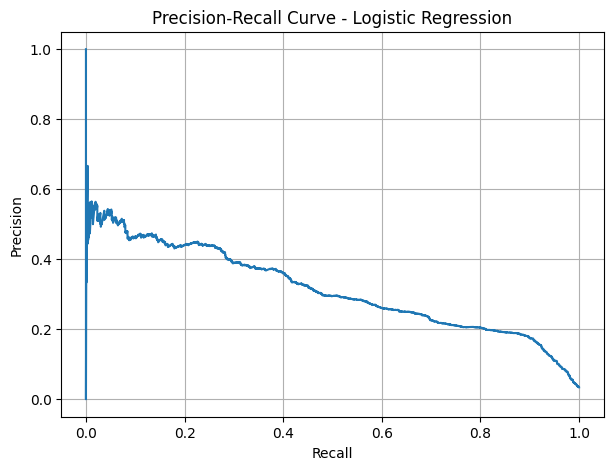

In [49]:
# ==========================================================
# 🎯 STEP 9: Threshold Optimization
# ==========================================================

from sklearn.metrics import precision_recall_curve, f1_score, fbeta_score
import numpy as np
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

# Compute F1 and F2 for each threshold
f1_scores = []
f2_scores = []

for t in thresholds:
    preds = (y_prob_lr >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))
    f2_scores.append(fbeta_score(y_test, preds, beta=2))

f1_scores = np.array(f1_scores)
f2_scores = np.array(f2_scores)

best_f1_threshold = thresholds[np.argmax(f1_scores)]
best_f2_threshold = thresholds[np.argmax(f2_scores)]

print("Best F1 threshold:", best_f1_threshold)
print("Best F2 threshold (recall focused):", best_f2_threshold)

# Plot Precision-Recall Curve
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.grid(True)
plt.show()


In [50]:
# ==========================================================
# 📊 STEP 10: Compare Threshold Strategies
# ==========================================================

from sklearn.metrics import classification_report

thresholds_to_test = {
    "Default (0.5)": 0.5,
    "Best F1": best_f1_threshold,
    "Best F2 (Recall Focused)": best_f2_threshold
}

for name, thresh in thresholds_to_test.items():
    preds = (y_prob_lr >= thresh).astype(int)
    
    print("\n" + "="*60)
    print(f"Threshold Strategy: {name} | Threshold = {thresh:.4f}")
    print("="*60)
    print(classification_report(y_test, preds, target_names=['Non-Fraud','Fraud']))



Threshold Strategy: Default (0.5) | Threshold = 0.5000
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.86      0.92     31994
       Fraud       0.18      0.89      0.30      1127

    accuracy                           0.86     33121
   macro avg       0.59      0.87      0.61     33121
weighted avg       0.97      0.86      0.90     33121


Threshold Strategy: Best F1 | Threshold = 0.8618
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.97      0.98     31994
       Fraud       0.36      0.40      0.38      1127

    accuracy                           0.96     33121
   macro avg       0.67      0.69      0.68     33121
weighted avg       0.96      0.96      0.96     33121


Threshold Strategy: Best F2 (Recall Focused) | Threshold = 0.5258
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.87      0.93     31994
       Fraud       0.19      0.87      0.31      1127

    accur

In [51]:
# ==========================================================
# 🌳 STEP 11: Train Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_final)
y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]

print("\nRANDOM FOREST RESULTS")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Fraud','Fraud']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nROC-AUC: {auc_rf:.4f}")


Training Random Forest...

RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.97      1.00      0.99     31994
       Fraud       0.82      0.18      0.29      1127

    accuracy                           0.97     33121
   macro avg       0.89      0.59      0.64     33121
weighted avg       0.97      0.97      0.96     33121


Confusion Matrix:
[[31949    45]
 [  927   200]]

ROC-AUC: 0.9548


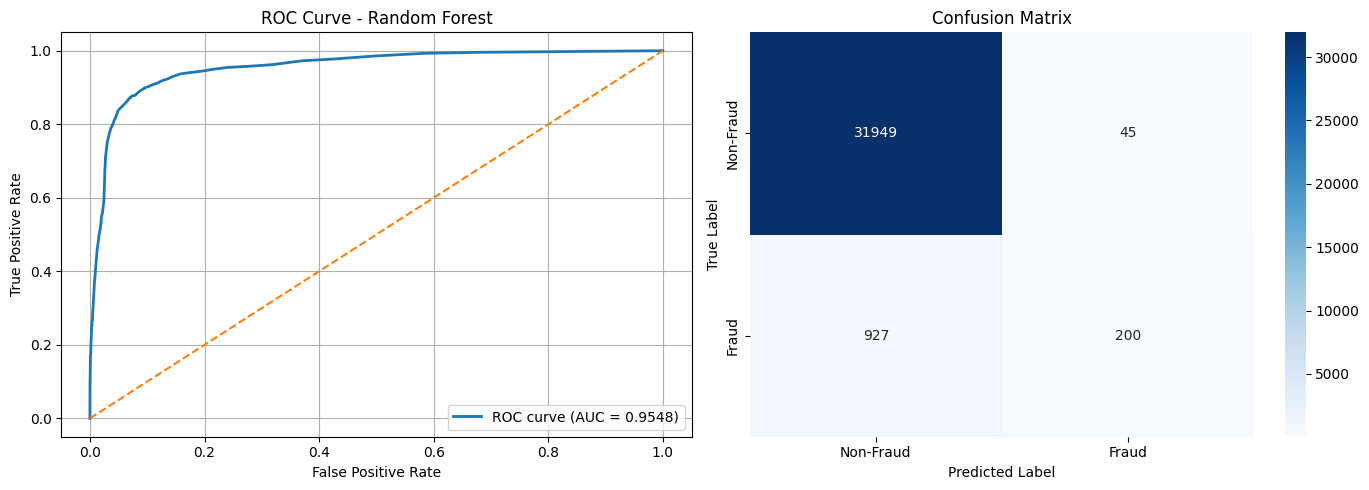

✅ Random Forest visualization complete.


In [52]:
# ==========================================================
# 📊 STEP 12: Visualize Random Forest Performance
# ==========================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr_rf, tpr_rf, lw=2, label=f'ROC curve (AUC = {auc_rf:.4f})')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print("✅ Random Forest visualization complete.")


In [53]:
# ==========================================================
# 🎯 STEP 13: Optimize Random Forest Threshold
# ==========================================================

from sklearn.metrics import precision_recall_curve
import numpy as np

precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)

# Compute F1 scores
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-8)

best_f1_index_rf = np.argmax(f1_scores_rf)
best_threshold_f1_rf = thresholds_rf[best_f1_index_rf]

print("Best F1 Threshold (Random Forest):", best_threshold_f1_rf)


Best F1 Threshold (Random Forest): 0.15333333333333332


In [54]:
# ==========================================================
# 🎯 STEP 14: Evaluate Random Forest at Best F1 Threshold
# ==========================================================

# Apply optimized threshold
y_pred_rf_f1 = (y_prob_rf >= best_threshold_f1_rf).astype(int)

print("="*60)
print(f"Random Forest - Best F1 Threshold ({best_threshold_f1_rf:.4f})")
print("="*60)

print(classification_report(y_test, y_pred_rf_f1, target_names=['Non-Fraud','Fraud']))

cm_rf_f1 = confusion_matrix(y_test, y_pred_rf_f1)
print("\nConfusion Matrix:")
print(cm_rf_f1)

# Extract fraud metrics
tn, fp, fn, tp = cm_rf_f1.ravel()

fraud_precision = tp / (tp + fp)
fraud_recall = tp / (tp + fn)

print("\nFraud Precision:", round(fraud_precision, 4))
print("Fraud Recall:", round(fraud_recall, 4))


Random Forest - Best F1 Threshold (0.1533)
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.97      0.98     31994
       Fraud       0.47      0.75      0.58      1127

    accuracy                           0.96     33121
   macro avg       0.73      0.86      0.78     33121
weighted avg       0.97      0.96      0.97     33121


Confusion Matrix:
[[31042   952]
 [  285   842]]

Fraud Precision: 0.4693
Fraud Recall: 0.7471


In [55]:
# ==========================================================
# 🚀 STEP 15: Train XGBoost
# ==========================================================

from xgboost import XGBClassifier

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_test_final)
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:,1]

print("XGBoost training complete.")


Training XGBoost...
XGBoost training complete.


In [56]:
# ==========================================================
# 🚀 STEP 16: Evaluate XGBoost (Default 0.5 Threshold)
# ==========================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("="*60)
print("XGBOOST RESULTS (Default Threshold = 0.5)")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Fraud','Fraud']))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"\nROC-AUC: {auc_xgb:.4f}")


XGBOOST RESULTS (Default Threshold = 0.5)

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.95      0.97     31994
       Fraud       0.35      0.78      0.49      1127

    accuracy                           0.94     33121
   macro avg       0.67      0.87      0.73     33121
weighted avg       0.97      0.94      0.95     33121


Confusion Matrix:
[[30385  1609]
 [  245   882]]

ROC-AUC: 0.9472


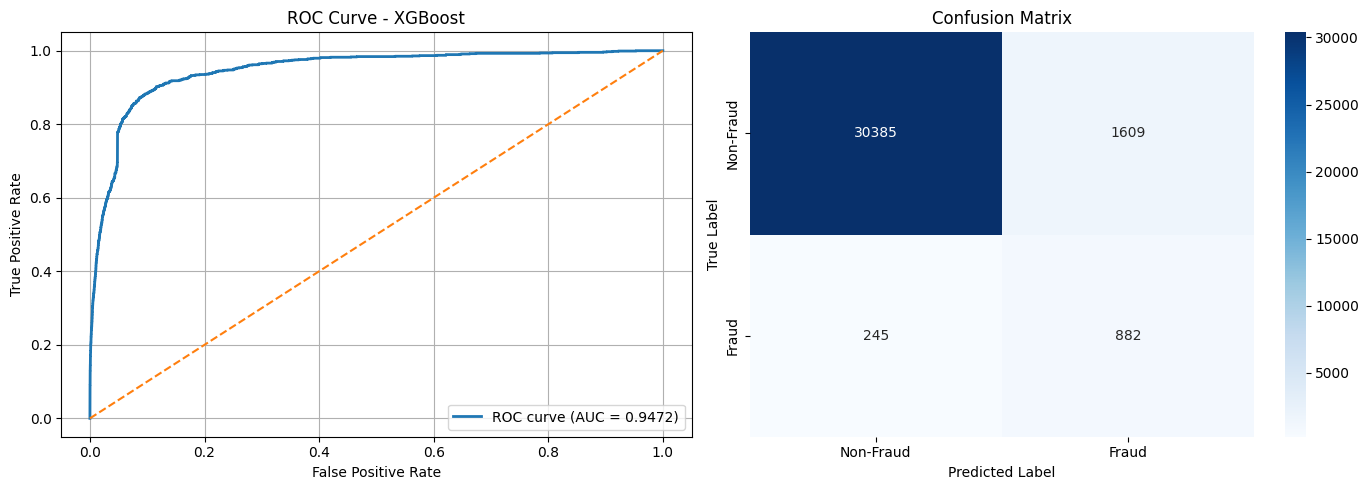

✅ XGBoost visualization complete.


In [57]:
# ==========================================================
# 📊 STEP 17: Visualize XGBoost Performance
# ==========================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr_xgb, tpr_xgb, lw=2, label=f'ROC curve (AUC = {auc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - XGBoost')
axes[0].legend()
axes[0].grid(True)

# Confusion Matrix
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print("✅ XGBoost visualization complete.")


In [58]:
# ==========================================================
# 🎯 STEP 18: Optimize XGBoost Threshold
# ==========================================================

from sklearn.metrics import precision_recall_curve
import numpy as np

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

# Compute F1 scores
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-8)

best_f1_index_xgb = np.argmax(f1_scores_xgb)
best_threshold_f1_xgb = thresholds_xgb[best_f1_index_xgb]

print("Best F1 Threshold (XGBoost):", best_threshold_f1_xgb)


Best F1 Threshold (XGBoost): 0.778811


In [59]:
# ==========================================================
# 🎯 STEP 19: Evaluate XGBoost at Best F1 Threshold
# ==========================================================

# Apply optimized threshold
y_pred_xgb_f1 = (y_prob_xgb >= best_threshold_f1_xgb).astype(int)

print("="*60)
print(f"XGBoost - Best F1 Threshold ({best_threshold_f1_xgb:.4f})")
print("="*60)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_xgb_f1, 
                            target_names=['Non-Fraud','Fraud']))

cm_xgb_f1 = confusion_matrix(y_test, y_pred_xgb_f1)
print("\nConfusion Matrix:")
print(cm_xgb_f1)

# Extract fraud metrics
tn, fp, fn, tp = cm_xgb_f1.ravel()

fraud_precision_xgb = tp / (tp + fp)
fraud_recall_xgb = tp / (tp + fn)
fraud_f1_xgb = 2 * (fraud_precision_xgb * fraud_recall_xgb) / \
               (fraud_precision_xgb + fraud_recall_xgb + 1e-8)

print("\nFraud Precision:", round(fraud_precision_xgb, 4))
print("Fraud Recall:", round(fraud_recall_xgb, 4))
print("Fraud F1:", round(fraud_f1_xgb, 4))


XGBoost - Best F1 Threshold (0.7788)
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.98      0.98     31994
       Fraud       0.51      0.50      0.51      1127

    accuracy                           0.97     33121
   macro avg       0.75      0.74      0.74     33121
weighted avg       0.97      0.97      0.97     33121


Confusion Matrix:
[[31442   552]
 [  558   569]]

Fraud Precision: 0.5076
Fraud Recall: 0.5049
Fraud F1: 0.5062


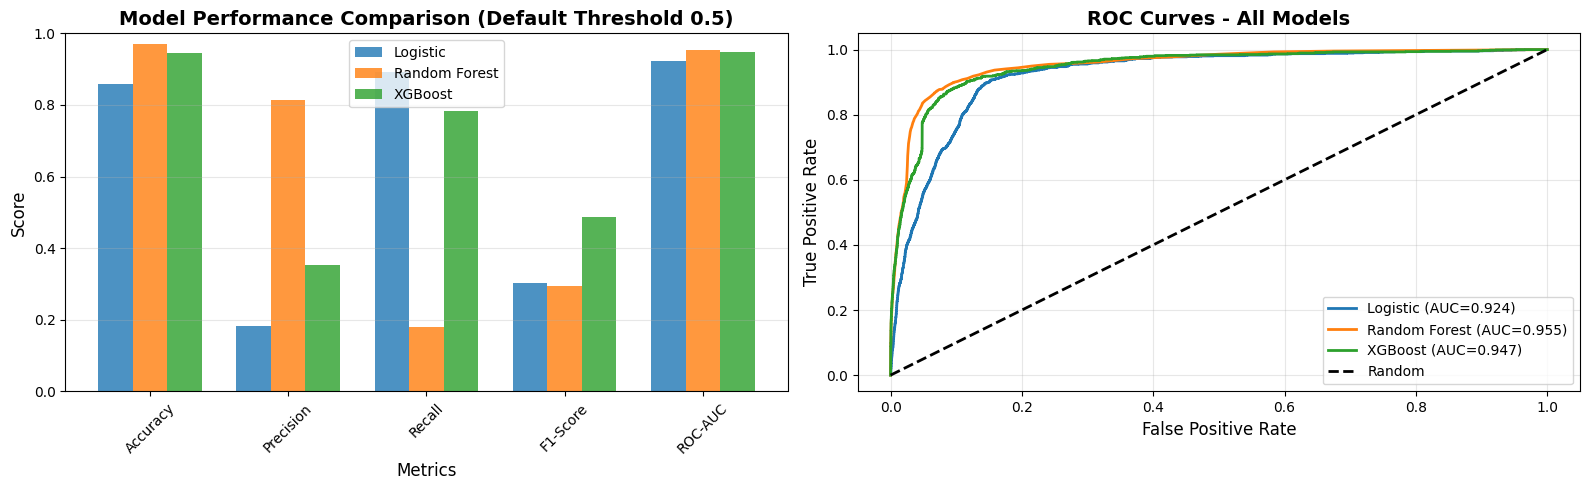


✅ Model comparison complete!


In [60]:
# ==========================================================
# 📊 MODEL COMPARISON (All 3 Models)
# ==========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Recompute probabilities if needed
# ----------------------------------------------------------

y_prob_lr = lr_model.predict_proba(X_test_final)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# Default threshold predictions (0.5)
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
y_pred_rf = (y_prob_rf >= 0.5).astype(int)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

# ----------------------------------------------------------
# Store results
# ----------------------------------------------------------

results = {
    "Logistic": {
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr),
        "recall": recall_score(y_test, y_pred_lr),
        "f1": f1_score(y_test, y_pred_lr),
        "roc_auc": roc_auc_score(y_test, y_prob_lr),
        "y_pred_proba": y_prob_lr
    },
    "Random Forest": {
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf),
        "recall": recall_score(y_test, y_pred_rf),
        "f1": f1_score(y_test, y_pred_rf),
        "roc_auc": roc_auc_score(y_test, y_prob_rf),
        "y_pred_proba": y_prob_rf
    },
    "XGBoost": {
        "accuracy": accuracy_score(y_test, y_pred_xgb),
        "precision": precision_score(y_test, y_pred_xgb),
        "recall": recall_score(y_test, y_pred_xgb),
        "f1": f1_score(y_test, y_pred_xgb),
        "roc_auc": roc_auc_score(y_test, y_prob_xgb),
        "y_pred_proba": y_prob_xgb
    }
}

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = range(len(metrics))
width = 0.25

for i, model_name in enumerate(results.keys()):
    values = [results[model_name][key] for key in metric_keys]
    axes[0].bar([xi + i*width for xi in x], values, width, label=model_name, alpha=0.8)

axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison (Default Threshold 0.5)', fontsize=14, fontweight='bold')
axes[0].set_xticks([xi + width for xi in x])
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: ROC Curves
for model_name in results.keys():
    fpr_temp, tpr_temp, _ = roc_curve(y_test, results[model_name]['y_pred_proba'])
    auc_temp = results[model_name]['roc_auc']
    axes[1].plot(fpr_temp, tpr_temp, lw=2, label=f'{model_name} (AUC={auc_temp:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model comparison complete!")


In [65]:
# ==========================================================
# 🧪 ABLATION 1: Text-Only Model (Random Forest)
# ==========================================================
import time
from sklearn.metrics import precision_recall_curve

start = time.time()

rf_text = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_text.fit(X_train_text, y_train)

y_prob_text = rf_text.predict_proba(X_test_text)[:,1]

# Find optimal threshold for THIS model
prec_t, rec_t, thresh_t = precision_recall_curve(y_test, y_prob_text)
f1_t = 2 * (prec_t * rec_t) / (prec_t + rec_t + 1e-8)
best_thresh_text = thresh_t[np.argmax(f1_t)]

y_pred_text = (y_prob_text >= best_thresh_text).astype(int)

print(f"Text-Only Best F1 Threshold: {best_thresh_text:.4f}")
print(f"Training time: {time.time() - start:.1f}s")
print("\nText-Only Performance:")
print(classification_report(y_test, y_pred_text))

Text-Only Best F1 Threshold: 0.6297
Training time: 26.7s

Text-Only Performance:
              precision    recall  f1-score   support

       False       0.98      0.97      0.97     31994
        True       0.28      0.35      0.31      1127

    accuracy                           0.95     33121
   macro avg       0.63      0.66      0.64     33121
weighted avg       0.95      0.95      0.95     33121



In [66]:
# ==========================================================
# 🧪 ABLATION 2: Structured-Only Model
# ==========================================================
import time
from sklearn.metrics import precision_recall_curve

# Combine structured features only
X_train_struct = sp.hstack([X_train_cat, X_train_num])
X_test_struct = sp.hstack([X_test_cat, X_test_num])

start = time.time()

rf_struct = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_struct.fit(X_train_struct, y_train)

y_prob_struct = rf_struct.predict_proba(X_test_struct)[:,1]

# Find optimal threshold for THIS model
prec_s, rec_s, thresh_s = precision_recall_curve(y_test, y_prob_struct)
f1_s = 2 * (prec_s * rec_s) / (prec_s + rec_s + 1e-8)
best_thresh_struct = thresh_s[np.argmax(f1_s)]

y_pred_struct = (y_prob_struct >= best_thresh_struct).astype(int)

print(f"Structured-Only Best F1 Threshold: {best_thresh_struct:.4f}")
print(f"Training time: {time.time() - start:.1f}s")
print("\nStructured-Only Performance:")
print(classification_report(y_test, y_pred_struct))

Structured-Only Best F1 Threshold: 0.7120
Training time: 18.5s

Structured-Only Performance:
              precision    recall  f1-score   support

       False       0.98      0.97      0.98     31994
        True       0.36      0.43      0.39      1127

    accuracy                           0.96     33121
   macro avg       0.67      0.70      0.68     33121
weighted avg       0.96      0.96      0.96     33121



In [ ]:
# ==========================================================
# 📊 ABLATION COMPARISON
# ==========================================================

from sklearn.metrics import f1_score

# Use the hybrid model's best F1 threshold from Step 13
y_pred_hybrid = (y_prob_rf >= best_threshold_f1_rf).astype(int)

results_ablation = {
    "Text Only": f1_score(y_test, y_pred_text),
    "Structured Only": f1_score(y_test, y_pred_struct),
    "Hybrid (Full Model)": f1_score(y_test, y_pred_hybrid)
}

for k, v in results_ablation.items():
    print(f"{k}: F1 = {v:.4f}")

{'Text Only': 0.3214409421544856, 'Structured Only': 0.3622159090909091, 'Hybrid (Full Model)': 0.58}


Text Only: threshold=0.6297, time=31.7s
Structured Only: threshold=0.7120, time=17.1s

                      Precision    Recall        F1
Text Only             0.281560  0.352263  0.312968
Structured Only       0.364465  0.425909  0.392799
Hybrid (Full Model)   0.469342  0.747116  0.576515


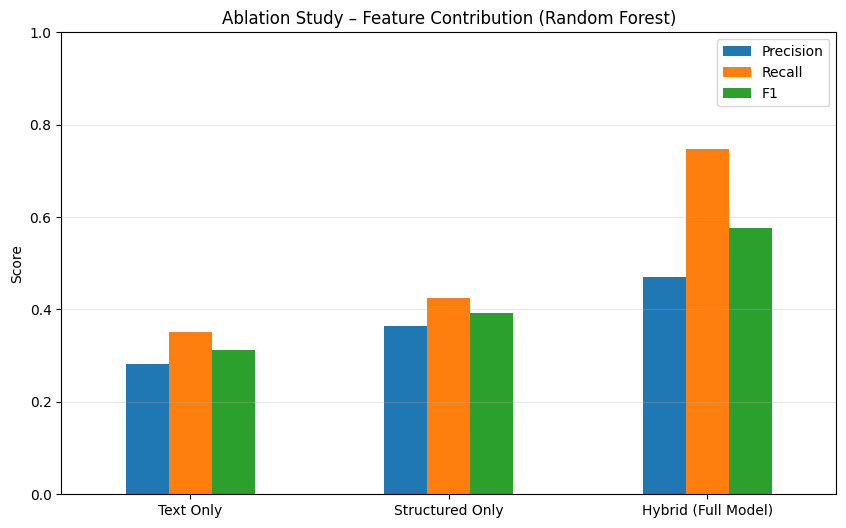

In [67]:
# ==========================================================
# 🧪 ABLATION STUDY – Random Forest (Side-by-Side)
# ==========================================================

from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

def find_best_f1_threshold(y_true, y_prob):
    """Find threshold that maximizes F1 score."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    return thresh[np.argmax(f1)]

results_ablation = {}

# -------------------------
# 1️⃣ Text Only
# -------------------------
start = time.time()
rf_text = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_text.fit(X_train_text, y_train)
y_prob_text = rf_text.predict_proba(X_test_text)[:,1]
thresh_text = find_best_f1_threshold(y_test, y_prob_text)
y_pred_text = (y_prob_text >= thresh_text).astype(int)
print(f"Text Only: threshold={thresh_text:.4f}, time={time.time()-start:.1f}s")

results_ablation["Text Only"] = {
    "Precision": precision_score(y_test, y_pred_text),
    "Recall": recall_score(y_test, y_pred_text),
    "F1": f1_score(y_test, y_pred_text)
}

# -------------------------
# 2️⃣ Structured Only
# -------------------------
start = time.time()
X_train_struct = sp.hstack([X_train_cat, X_train_num])
X_test_struct = sp.hstack([X_test_cat, X_test_num])

rf_struct = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_struct.fit(X_train_struct, y_train)
y_prob_struct = rf_struct.predict_proba(X_test_struct)[:,1]
thresh_struct = find_best_f1_threshold(y_test, y_prob_struct)
y_pred_struct = (y_prob_struct >= thresh_struct).astype(int)
print(f"Structured Only: threshold={thresh_struct:.4f}, time={time.time()-start:.1f}s")

results_ablation["Structured Only"] = {
    "Precision": precision_score(y_test, y_pred_struct),
    "Recall": recall_score(y_test, y_pred_struct),
    "F1": f1_score(y_test, y_pred_struct)
}

# -------------------------
# 3️⃣ Hybrid (Full Model) – reuse already-trained rf_model
# -------------------------
y_pred_full = (y_prob_rf >= best_threshold_f1_rf).astype(int)

results_ablation["Hybrid (Full Model)"] = {
    "Precision": precision_score(y_test, y_pred_full),
    "Recall": recall_score(y_test, y_pred_full),
    "F1": f1_score(y_test, y_pred_full)
}

# ----------------------------------------------------------
# Convert to DataFrame
# ----------------------------------------------------------

ablation_df = pd.DataFrame(results_ablation).T
print("\n", ablation_df)

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

ablation_df.plot(kind='bar', figsize=(10,6))
plt.title("Ablation Study – Feature Contribution (Random Forest)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)
plt.show()

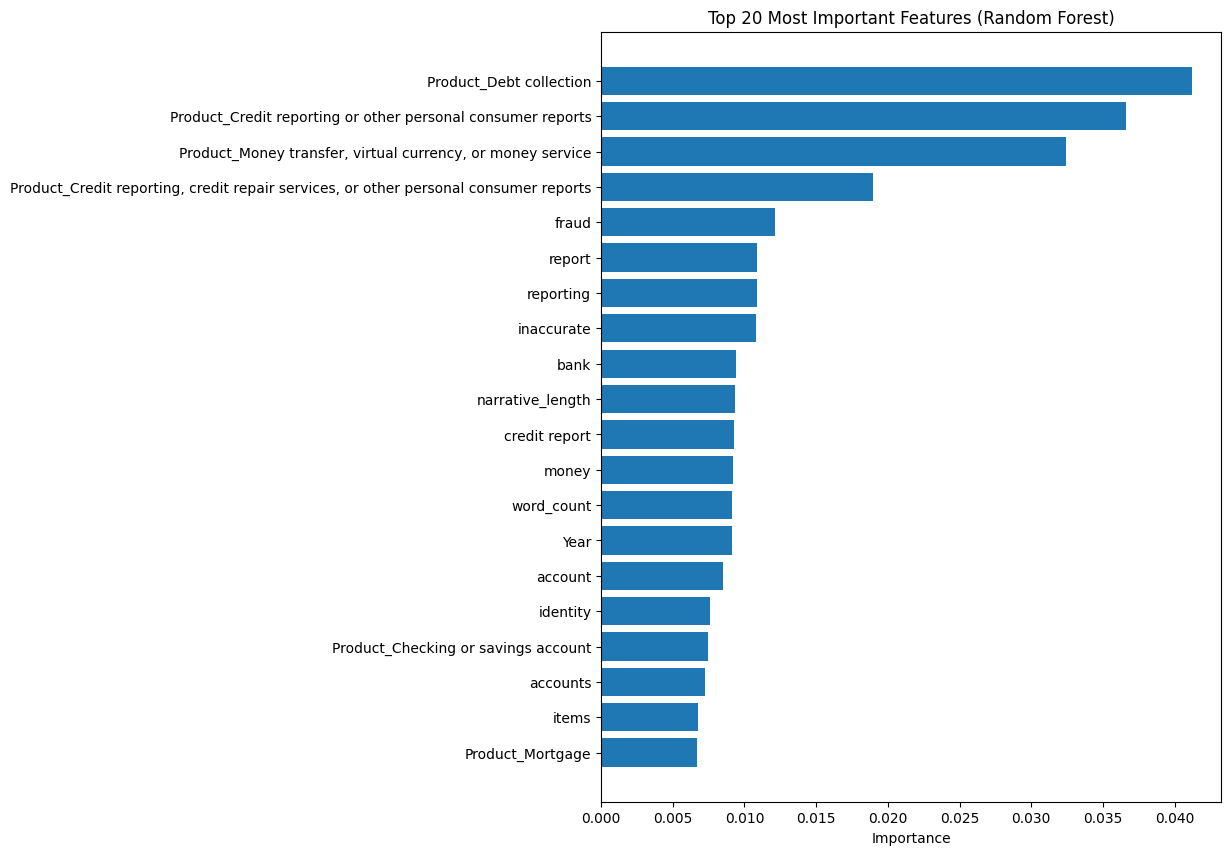

,Feature,Importance
1005,Product_Debt collection,0.041183
1003,Product_Credit reporting or other personal con...,0.036619
1007,"Product_Money transfer, virtual currency, or m...",0.032412
1004,"Product_Credit reporting, credit repair servic...",0.018994
407,fraud,0.012112
771,report,0.010875
782,reporting,0.010853
465,inaccurate,0.010792
109,bank,0.009410
1078,narrative_length,0.009341


In [68]:
# ==========================================================
# 🌳 FEATURE IMPORTANCE – Random Forest (Hybrid Model)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Get Feature Names in Correct Order
# ----------------------------------------------------------

# Text features
text_feature_names = tfidf.get_feature_names_out()

# Categorical features (OneHot)
cat_feature_names = ohe.get_feature_names_out(['Product','State'])

# Numeric features
num_feature_names = numeric_features

# Combine in correct order
all_feature_names = np.concatenate([
    text_feature_names,
    cat_feature_names,
    num_feature_names
])

# ----------------------------------------------------------
# Extract Importances
# ----------------------------------------------------------

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# ----------------------------------------------------------
# Top 20 Features
# ----------------------------------------------------------

top_features = feature_importance_df.head(20)

plt.figure(figsize=(8,10))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

top_features.head(20)


In [69]:
# ==========================================================
# 🔎 STEP 21: Failure Analysis – False Negatives (Missed Fraud)
# ==========================================================

import pandas as pd

# Get indices aligned with test set
test_indices = test_df.index

# Build dataframe with predictions
failure_df = test_df.copy()
failure_df['y_true'] = y_test.values
failure_df['y_prob_xgb'] = y_prob_xgb
failure_df['y_pred_xgb_f1'] = y_pred_xgb_f1

# False Negatives = actual fraud but predicted non-fraud
false_negatives = failure_df[
    (failure_df['y_true'] == 1) &
    (failure_df['y_pred_xgb_f1'] == 0)
]

print("Total Fraud Cases in Test:", y_test.sum())
print("False Negatives (Missed Fraud):", len(false_negatives))
print("Miss Rate:", round(len(false_negatives)/y_test.sum(), 4))


Total Fraud Cases in Test: 1127
False Negatives (Missed Fraud): 558
Miss Rate: 0.4951


In [71]:
# ==========================================================
# 🔎 Analyze Product Distribution in Missed Fraud
# ==========================================================

print("\nTop Products in Missed Fraud:")
print(false_negatives['Product'].value_counts().head(10))

print("\nTop States in Missed Fraud:")
print(false_negatives['State'].value_counts().head(10))

print("\nAverage Narrative Length (Missed Fraud):",
      false_negatives['narrative_length'].mean())

print("Average Narrative Length (All Fraud):",
      failure_df[failure_df['y_true']==1]['narrative_length'].mean())



Top Products in Missed Fraud:
Product
Debt collection                                            298
Credit reporting or other personal consumer reports        126
Checking or savings account                                 88
Money transfer, virtual currency, or money service          31
Credit card                                                  7
Debt or credit management                                    4
Payday loan, title loan, personal loan, or advance loan      2
Mortgage                                                     1
Student loan                                                 1
Name: count, dtype: int64

Top States in Missed Fraud:
State
TX    114
CA     56
FL     52
GA     42
IL     36
NJ     20
PA     19
NY     18
NC     18
VA     17
Name: count, dtype: int64

Average Narrative Length (Missed Fraud): 883.2544802867384
Average Narrative Length (All Fraud): 903.6548358473824


In [ ]:
# Show sample missed fraud complaints
false_negatives[['Product', 'narrative_clean']].head(5)


,Product,narrative_clean
117268,Debt collection,i requested to have this debt removed from my ...
130452,"Money transfer, virtual currency, or money ser...",on x x x i sent x to someone i was supposed to...
4062,Debt collection,the fair credit reporting act u s code says th...
159497,Debt collection,the fair credit reporting act u s code says th...
62514,Credit reporting or other personal consumer re...,equifax has failed to update my credit report ...


In [72]:
# ==========================================================
# 🔎 Compare Missed Fraud vs Correctly Detected Fraud
# ==========================================================

# True Positives (correctly detected fraud)
true_positives = failure_df[
    (failure_df['y_true'] == 1) &
    (failure_df['y_pred_xgb_f1'] == 1)
]

print("Avg Narrative Length - True Positives:",
      true_positives['narrative_length'].mean())

print("Avg Word Count - Missed Fraud:",
      false_negatives['word_count'].mean())

print("Avg Word Count - True Positives:",
      true_positives['word_count'].mean())


Avg Narrative Length - True Positives: 923.6608084358523
Avg Word Count - Missed Fraud: 161.4390681003584
Avg Word Count - True Positives: 168.3602811950791


In [74]:
# ==========================================================
# 🔬 HYPERPARAMETER SENSITIVITY ANALYSIS (Random Forest)
# ==========================================================

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import time

# Subsample for speed (HP search doesn't need 100K+ rows)
np.random.seed(42)
n_sub = min(20000, X_train_final.shape[0])
idx = np.random.choice(X_train_final.shape[0], n_sub, replace=False)
X_hp = X_train_final[idx]
y_hp = y_train.iloc[idx]

print(f"Using {n_sub} rows for HP sensitivity analysis\n")

# Test sensitivity to number of trees and max_depth
n_estimators_list = [100, 200, 300]
max_depth_list = [10, 20, 30]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results_hp = []

for n in n_estimators_list:
    for depth in max_depth_list:
        start = time.time()
        
        rf_temp = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        
        cv_results = cross_validate(
            rf_temp,
            X_hp,
            y_hp,
            cv=skf,
            scoring='f1'
        )
        
        elapsed = time.time() - start
        mean_f1 = np.mean(cv_results['test_score'])
        std_f1 = np.std(cv_results['test_score'])
        
        print(f"n_estimators={n}, max_depth={depth}: F1={mean_f1:.4f} ± {std_f1:.4f} ({elapsed:.1f}s)")
        
        results_hp.append({
            "n_estimators": n,
            "max_depth": depth,
            "Mean F1": mean_f1,
            "Std F1": std_f1
        })

hp_df = pd.DataFrame(results_hp)
hp_df.sort_values("Mean F1", ascending=False)

Using 20000 rows for HP sensitivity analysis

n_estimators=100, max_depth=10: F1=0.2902 ± 0.0100 (0.9s)
n_estimators=100, max_depth=20: F1=0.4033 ± 0.0182 (1.3s)
n_estimators=100, max_depth=30: F1=0.4346 ± 0.0294 (1.5s)
n_estimators=200, max_depth=10: F1=0.2863 ± 0.0058 (1.6s)
n_estimators=200, max_depth=20: F1=0.3944 ± 0.0209 (2.3s)
n_estimators=200, max_depth=30: F1=0.4370 ± 0.0272 (3.4s)
n_estimators=300, max_depth=10: F1=0.2881 ± 0.0072 (3.3s)
n_estimators=300, max_depth=20: F1=0.4039 ± 0.0231 (4.4s)
n_estimators=300, max_depth=30: F1=0.4435 ± 0.0253 (5.4s)


,n_estimators,max_depth,Mean F1,Std F1
8,300,30,0.443498,0.025302
5,200,30,0.437037,0.027179
2,100,30,0.434568,0.029362
7,300,20,0.403910,0.023124
1,100,20,0.403322,0.018181
4,200,20,0.394416,0.020939
0,100,10,0.290218,0.010040
6,300,10,0.288073,0.007186
3,200,10,0.286303,0.005850


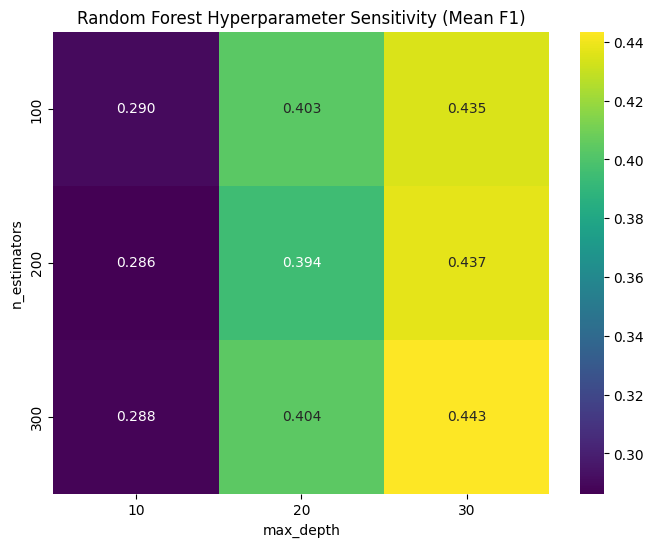

In [75]:
# ==========================================================
# 📊 Visualize Hyperparameter Sensitivity
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    hp_df.pivot(index="n_estimators", columns="max_depth", values="Mean F1"),
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Random Forest Hyperparameter Sensitivity (Mean F1)")
plt.show()


In [76]:
# ==========================================================
# 📊 5-FOLD CROSS-VALIDATION ACROSS MODEL FAMILIES
# ==========================================================

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import time

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for name, model in models.items():
    print(f"Running 5-fold CV for {name}...")
    start = time.time()
    
    scores = cross_validate(
        model,
        X_train_final,
        y_train,
        cv=5,
        scoring='f1'
        # n_jobs removed — models already use n_jobs=-1 internally
    )
    
    elapsed = time.time() - start
    mean_f1 = np.mean(scores['test_score'])
    std_f1 = np.std(scores['test_score'])
    
    print(f"  → Mean F1: {mean_f1:.4f} ± {std_f1:.4f} ({elapsed:.1f}s)")
    
    cv_results.append({
        "Model": name,
        "Mean F1 (5-fold CV)": mean_f1,
        "Std F1": std_f1
    })

cv_df = pd.DataFrame(cv_results)
cv_df.sort_values("Mean F1 (5-fold CV)", ascending=False)

Running 5-fold CV for Logistic Regression...
  → Mean F1: 0.2554 ± 0.0389 (91.6s)
Running 5-fold CV for Random Forest...
  → Mean F1: 0.3239 ± 0.1070 (58.8s)
Running 5-fold CV for XGBoost...


C:\Users\kevallab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:32:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\kevallab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:32:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\kevallab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:33:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_en

  → Mean F1: 0.0590 ± 0.0268 (85.5s)


,Model,Mean F1 (5-fold CV),Std F1
1,Random Forest,0.323888,0.106994
0,Logistic Regression,0.255397,0.038937
2,XGBoost,0.058969,0.026804


In [77]:
# ==========================================================
# 🔍 FAILURE ANALYSIS – XGBoost (Best F1 Threshold)
# ==========================================================

# Build evaluation dataframe
eval_df = test_df.copy()
eval_df = eval_df.reset_index(drop=True)

eval_df["y_true"] = y_test.values
eval_df["y_pred"] = y_pred_xgb_f1
eval_df["y_prob"] = y_prob_xgb

# False Negatives (Missed Fraud)
false_negatives = eval_df[
    (eval_df["y_true"] == 1) &
    (eval_df["y_pred"] == 0)
]

# False Positives (Incorrectly Flagged)
false_positives = eval_df[
    (eval_df["y_true"] == 0) &
    (eval_df["y_pred"] == 1)
]

print("Total False Negatives:", len(false_negatives))
print("Total False Positives:", len(false_positives))


Total False Negatives: 558
Total False Positives: 552


In [78]:
# Show 3 specific missed fraud complaints
false_negatives_examples = false_negatives[
    ["Product", "State", "narrative_clean"]
].head(3)

false_negatives_examples


,Product,State,narrative_clean
131,Credit reporting or other personal consumer re...,CA,the glaring absence of concrete evidence to su...
207,Credit reporting or other personal consumer re...,LA,i have talked to the company about payments ma...
255,Checking or savings account,PA,my phone was stolen and someone gained access ...


In [79]:
# Show 3 incorrectly flagged complaints
false_positives_examples = false_positives[
    ["Product", "State", "narrative_clean"]
].head(3)

false_positives_examples


,Product,State,narrative_clean
12,Debt collection,TX,the company froze my daughters account for tod...
82,Checking or savings account,GA,on x x year we received in the mail a new debi...
192,"Money transfer, virtual currency, or money ser...",MA,i have had over held in my x paypal account fo...


In [80]:
print("Average Length - False Negatives:",
      false_negatives["narrative_length"].mean())

print("Average Length - False Positives:",
      false_positives["narrative_length"].mean())

print("Average Length - Correct Fraud:",
      eval_df[(eval_df["y_true"]==1) &
              (eval_df["y_pred"]==1)]["narrative_length"].mean())


Average Length - False Negatives: 883.2544802867384
Average Length - False Positives: 852.8097826086956
Average Length - Correct Fraud: 923.6608084358523
